We're going to run a grid of stars from 15+ solar masses for a range of metallicities to assess what masses lead to BH formation in COSMIC.

In [1]:
from cosmic.sample.initialbinarytable import InitialBinaryTable
from cosmic.evolve import Evolve
import numpy as np
import matplotlib.pyplot as plt
import cogsworth
from multiprocessing import Pool
import pandas as pd

%config InlineBackend.figure_format = 'retina'

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

Create two grids to handle most metallicities and high metallicities separately

In [45]:
initial_binaries = None

mass_range = np.arange(70, 80, 0.005)
m_flat = mass_range

initial_binaries = InitialBinaryTable.InitialBinaries(
    m1=mass_range,
    m2=np.zeros(len(m_flat)),
    porb=-1 * np.ones(len(m_flat)),
    ecc=-1 * np.ones(len(m_flat)),
    tphysf=13700 * np.ones(len(m_flat)),
    kstar1=np.ones(len(m_flat)),
    kstar2=np.zeros(len(m_flat)),
    metallicity=[0.007] * len(m_flat),
)

len(initial_binaries)

2000

In [4]:
initial_binaries["bin_num"] = initial_binaries.index

In [46]:
bpp, bcm, initC, kick_info = Evolve.evolve(initial_binaries, nproc=32, params="../simulations/params.ini")
final_bpp = bpp.drop_duplicates(subset="bin_num", keep="last")

In [29]:
final_bpp["mass_1"][kick_info[kick_info["star"] == 1]["natal_kick"] == 0]

2798    12.568937
2799    12.569329
2800    12.569721
2801    12.570115
2802    12.570508
          ...    
9995    15.265350
9996    15.265565
9997    15.265778
9998    15.265989
9999    15.266199
Name: mass_1, Length: 5152, dtype: float64

In [47]:
final_bpp["mass_1"][kick_info[kick_info["star"] == 1]["natal_kick"] == 0]

1231    14.044490
1232    14.045081
1233    14.045683
1234    14.046273
1235    14.046864
          ...    
1995    14.441387
1996    14.441964
1997    14.442536
1998    14.443112
1999    14.443668
Name: mass_1, Length: 769, dtype: float64

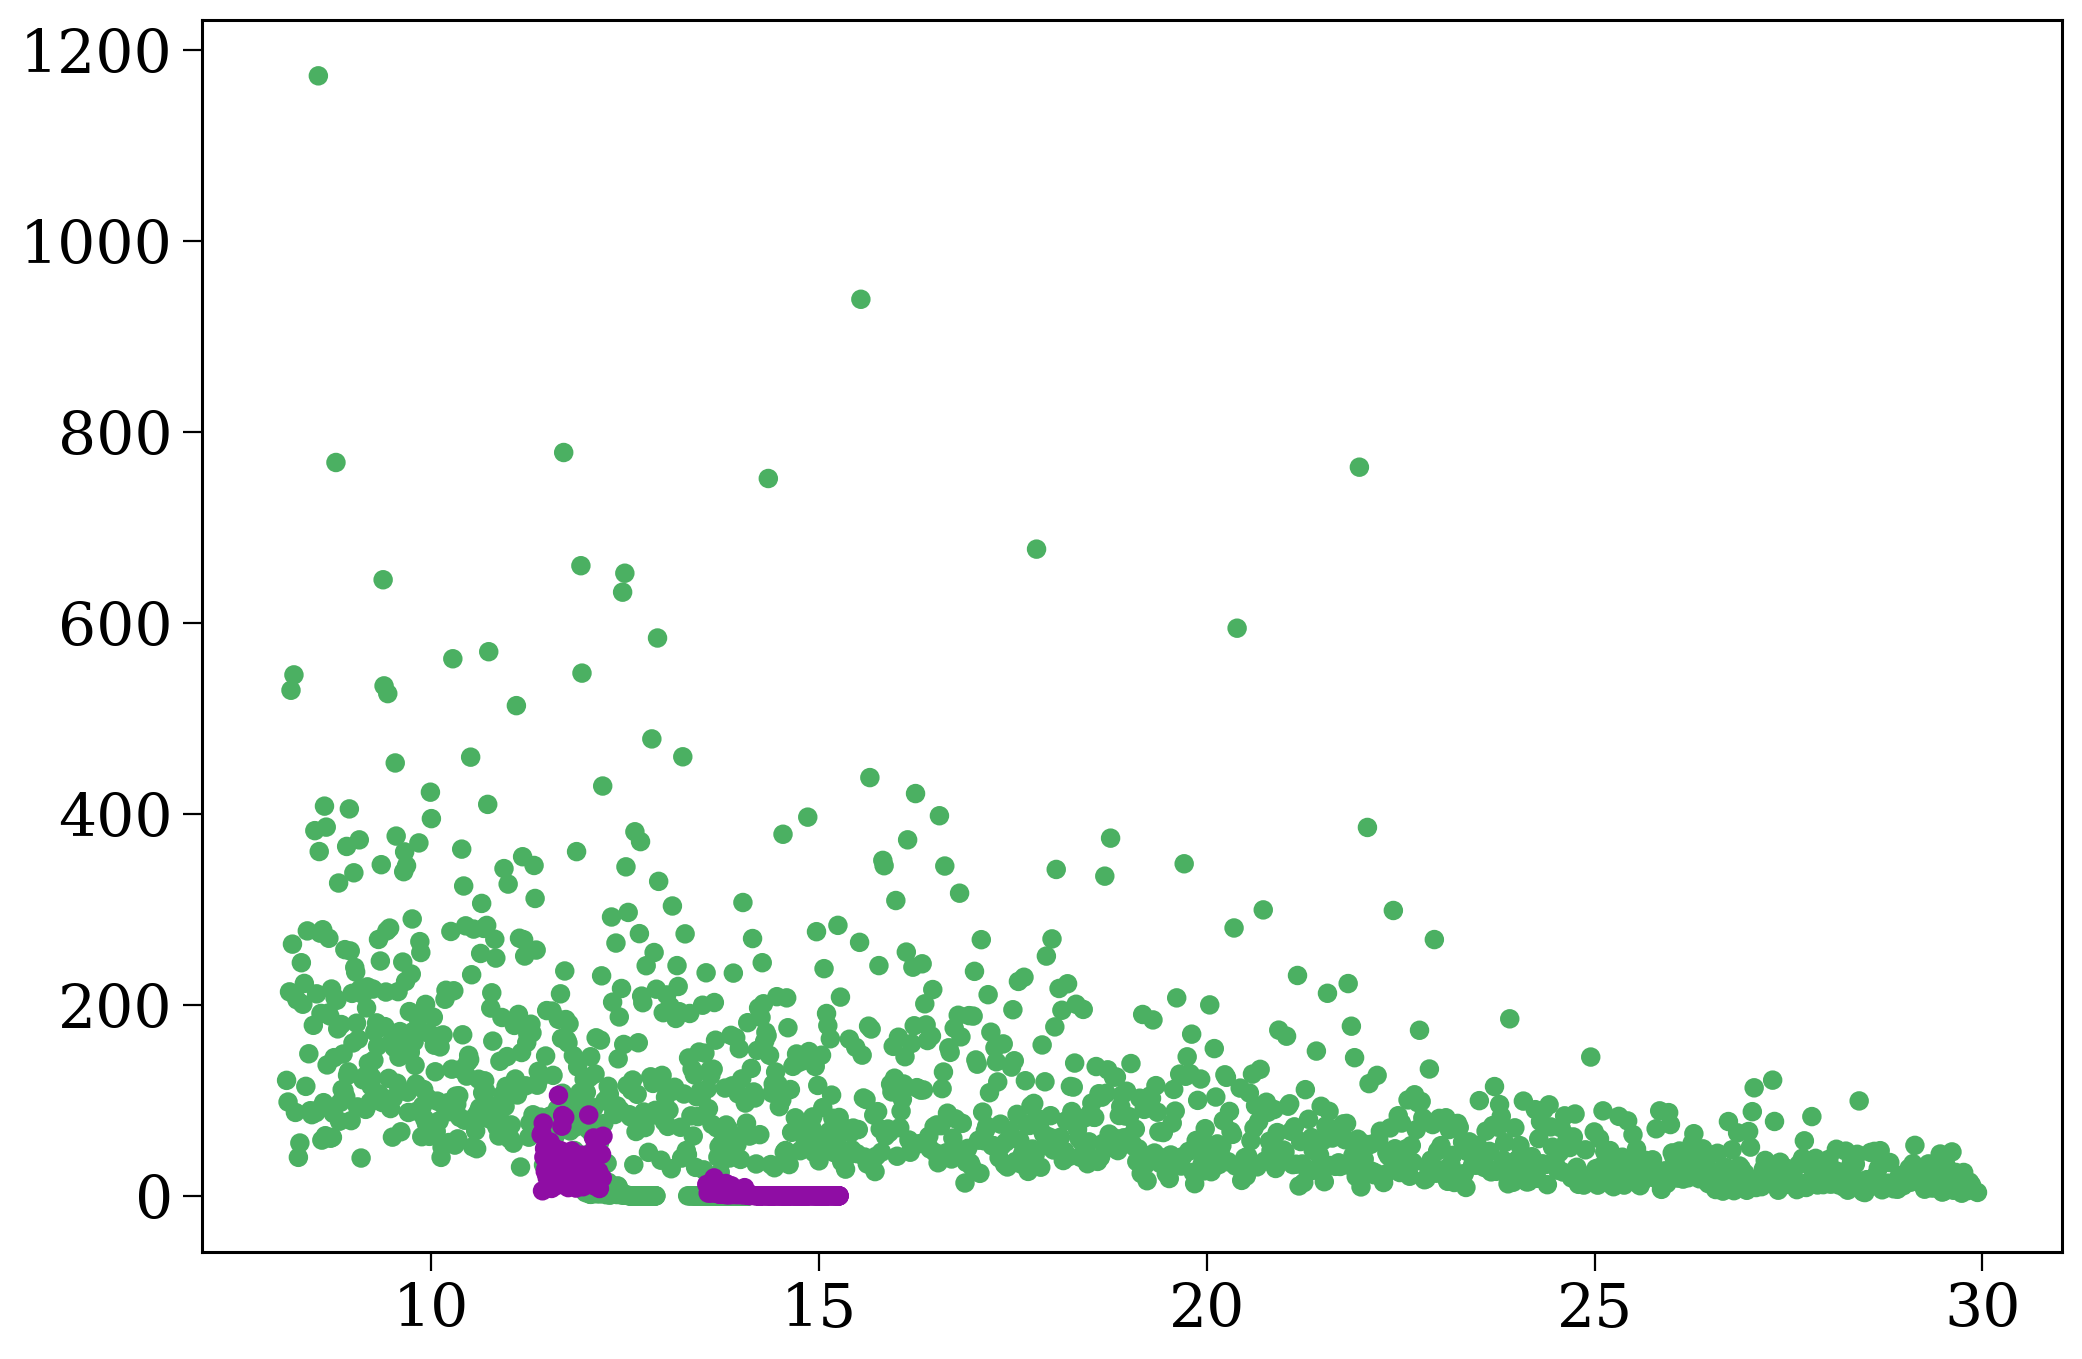

In [19]:
sn_rows = bpp[bpp["evol_type"] == 15]
co_mass = sn_rows["massc_co_layer_1"]

plt.scatter(final_bpp["mass_1"], kick_info[kick_info["star"] == 1]["natal_kick"], c=[cogsworth.utils.kstar_translator[k]["colour"] for k in sn_rows["kstar_1"]])

In [23]:
# find the minimum initial mass in initC where final_bpp has kstar_1 == 13
exploding_stars = final_bpp[final_bpp["kstar_1"] == 14]
exploding_initC = initC[initC["bin_num"].isin(exploding_stars["bin_num"])]
min_exploding_mass = exploding_initC.groupby("metallicity")["mass_1"].min().reset_index()
min_exploding_mass.to_hdf("~/ceph/underworld/cosmic_bh_crit.h5", key="min_bh_mass", mode="w")

<Axes: title={'center': 'Minimum Initial Mass for Core-Collapse vs Metallicity'}, xlabel='Metallicity', ylabel='Minimum Initial Mass for Core-Collapse (M$_\\odot$)'>

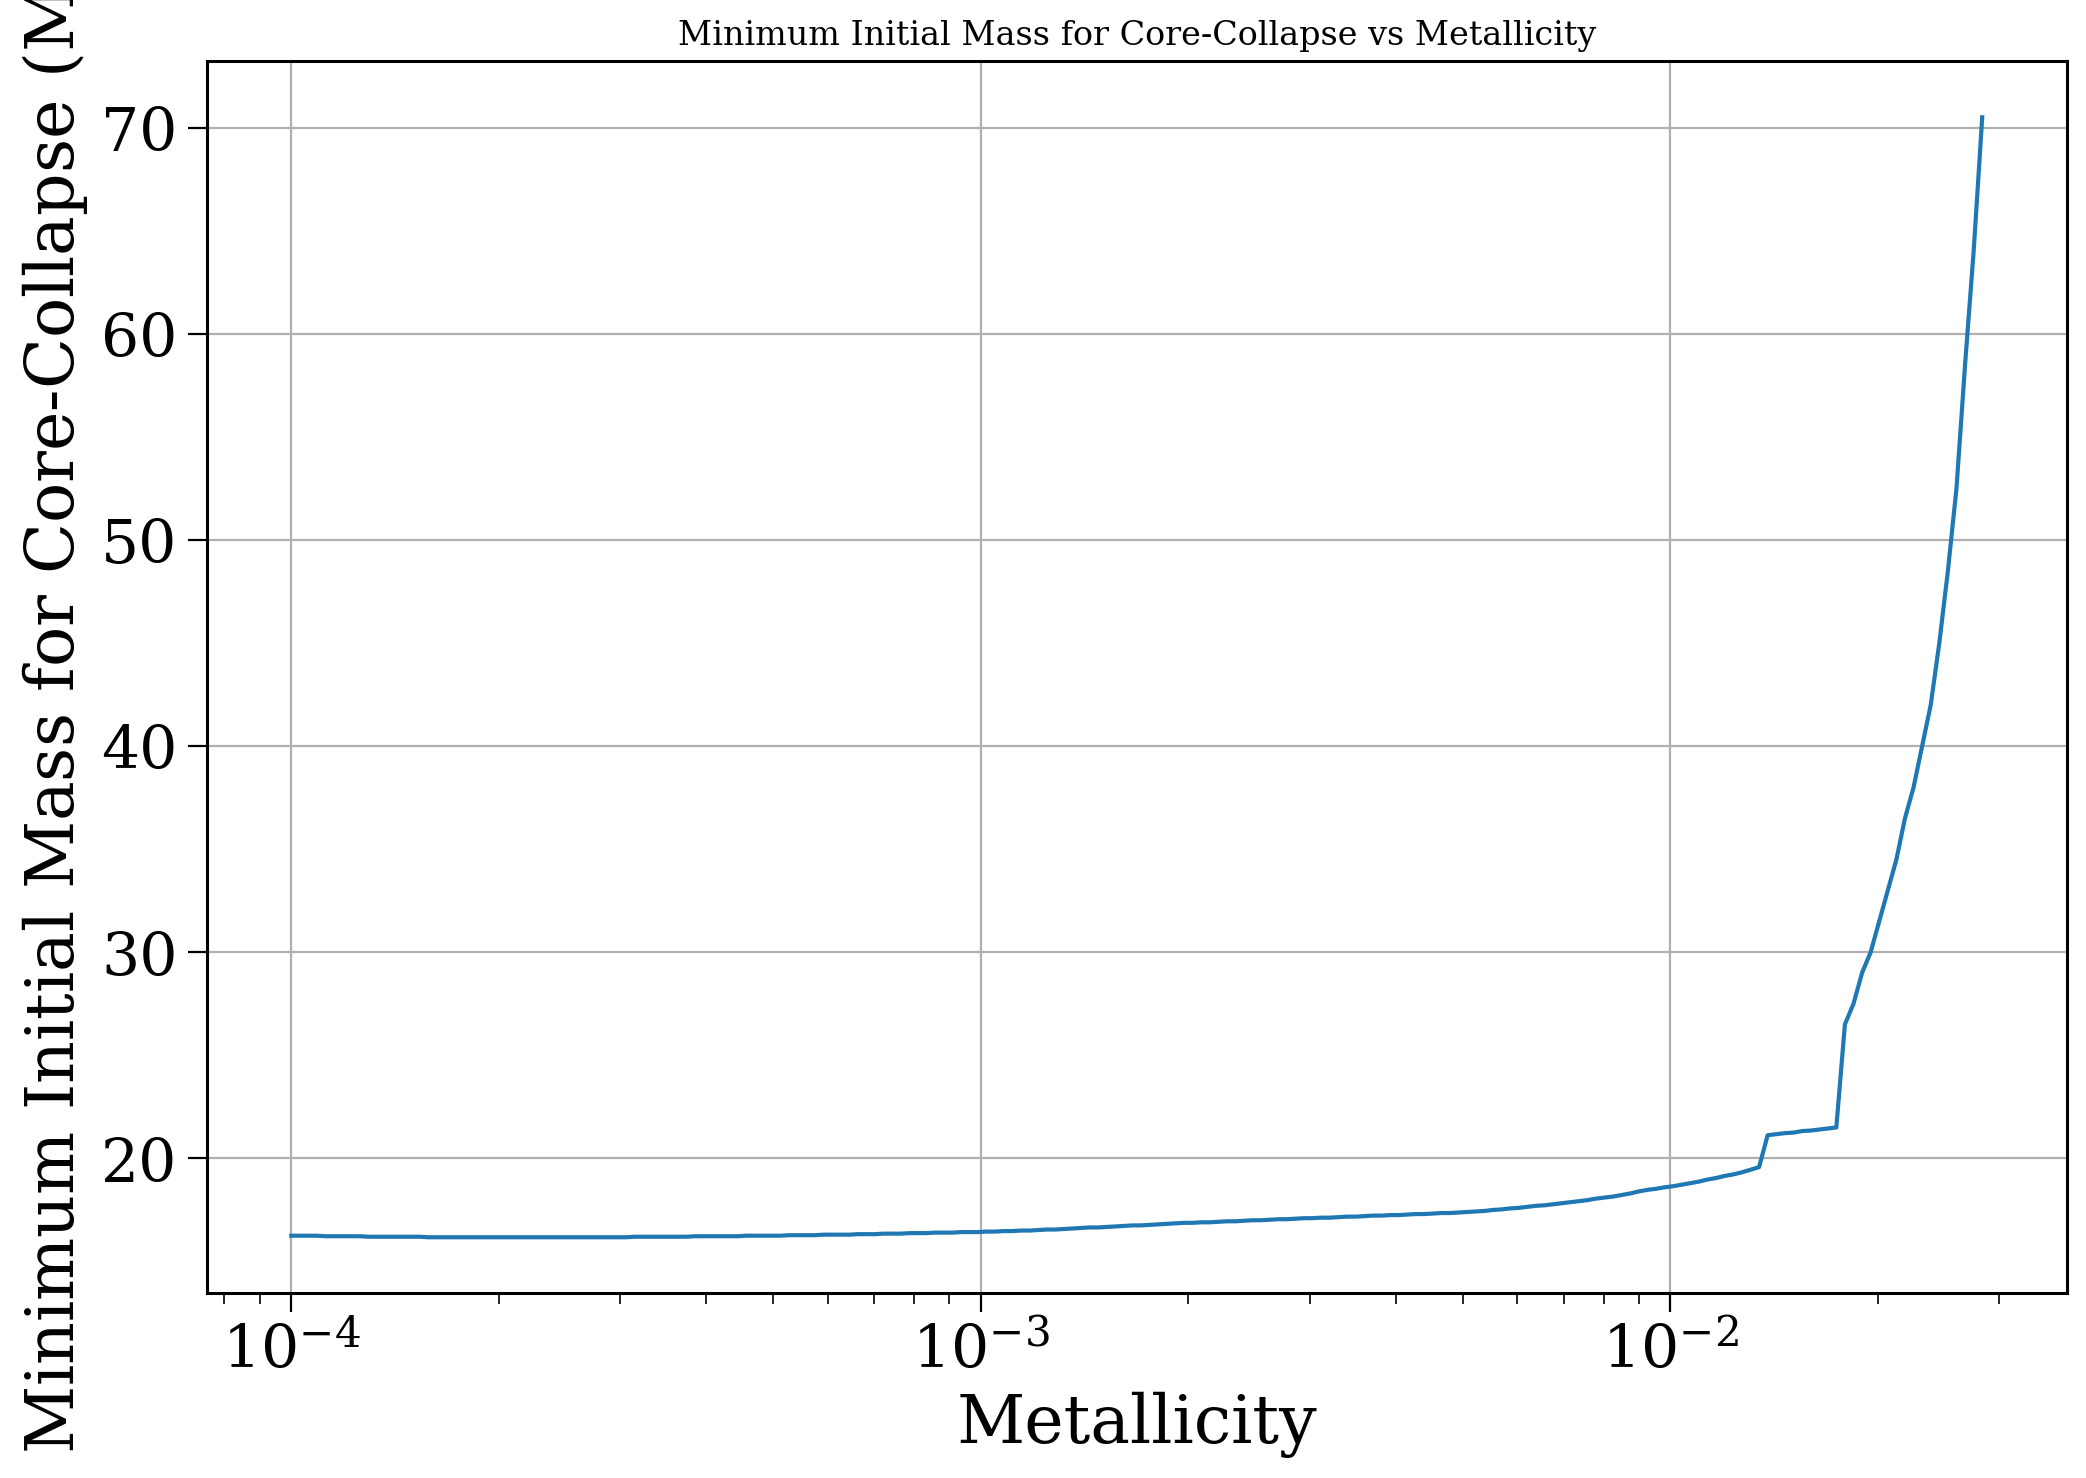

In [24]:
min_exploding_mass.plot(
    x="metallicity",
    y="mass_1",
    logx=True,
    xlabel="Metallicity",
    ylabel="Minimum Initial Mass for Core-Collapse (M$_\odot$)",
    title="Minimum Initial Mass for Core-Collapse vs Metallicity",
    legend=False,
    grid=True,
)

In [37]:
# find things in initC with metallicity between 0.02 and 0.03 and mass_1 between 70 and 72
initC[(initC["metallicity"] >= 0.02) & (initC["metallicity"] <= 0.03) & (initC["mass_1"] >= 70) & (initC["mass_1"] <= 72)]

,kstar_1,kstar_2,mass_1,mass_2,porb,ecc,metallicity,binfrac,tphysf,mass0_1,...,fprimc_6,fprimc_7,fprimc_8,fprimc_9,fprimc_10,fprimc_11,fprimc_12,fprimc_13,fprimc_14,fprimc_15
46792,1.0,0.0,72.0,0.0,-1.0,-1.0,0.020084,1.0,13700.0,72.0,...,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238
46726,1.0,0.0,70.5,0.0,-1.0,-1.0,0.020084,1.0,13700.0,70.5,...,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238
46704,1.0,0.0,70.0,0.0,-1.0,-1.0,0.020084,1.0,13700.0,70.0,...,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238
46748,1.0,0.0,71.0,0.0,-1.0,-1.0,0.020084,1.0,13700.0,71.0,...,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238
46770,1.0,0.0,71.5,0.0,-1.0,-1.0,0.020084,1.0,13700.0,71.5,...,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46762,1.0,0.0,71.0,0.0,-1.0,-1.0,0.030000,1.0,13700.0,71.0,...,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238
46718,1.0,0.0,70.0,0.0,-1.0,-1.0,0.030000,1.0,13700.0,70.0,...,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238
46806,1.0,0.0,72.0,0.0,-1.0,-1.0,0.030000,1.0,13700.0,72.0,...,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238
46784,1.0,0.0,71.5,0.0,-1.0,-1.0,0.030000,1.0,13700.0,71.5,...,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238


In [36]:
bpp.loc[46792]

,tphys,mass_1,mass_2,kstar_1,kstar_2,sep,porb,ecc,RRLO_1,RRLO_2,...,B_2,bacc_1,bacc_2,tacc_1,tacc_2,epoch_1,epoch_2,bhspin_1,bhspin_2,bin_num
46792,0.000000,72.000000,0.0,1,0,0.0,0.0,-1.0,0.0001,2.899082e-11,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,46792
46792,3.733808,45.922450,0.0,2,0,0.0,0.0,-1.0,0.0001,2.899082e-11,...,0.0,0.0,0.0,0.0,0.0,-0.473696,0.0,0.0,0.0,46792
46792,3.738000,17.163142,0.0,7,0,0.0,0.0,-1.0,0.0001,2.899082e-11,...,0.0,0.0,0.0,0.0,0.0,3.738000,0.0,0.0,0.0,46792
46792,4.331446,8.094723,0.0,8,0,0.0,0.0,-1.0,0.0001,2.899082e-11,...,0.0,0.0,0.0,0.0,0.0,3.579257,0.0,0.0,0.0,46792
46792,4.366026,7.723269,0.0,8,0,0.0,0.0,-1.0,0.0001,2.899082e-11,...,0.0,0.0,0.0,0.0,0.0,3.579257,0.0,0.0,0.0,46792
46792,4.366026,3.346162,0.0,14,0,0.0,0.0,-1.0,0.0001,2.899082e-11,...,0.0,0.0,0.0,0.0,0.0,4.366026,0.0,0.0,0.0,46792
46792,13700.000000,3.346162,0.0,14,0,0.0,0.0,-1.0,0.0001,2.899082e-11,...,0.0,0.0,0.0,0.0,0.0,4.366026,0.0,0.0,0.0,46792


In [38]:
bpp.loc[46806]

,tphys,mass_1,mass_2,kstar_1,kstar_2,sep,porb,ecc,RRLO_1,RRLO_2,...,B_2,bacc_1,bacc_2,tacc_1,tacc_2,epoch_1,epoch_2,bhspin_1,bhspin_2,bin_num
46806,0.000000,72.000000,0.0,1,0,0.0,0.0,-1.0,0.0001,2.815014e-11,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,46806
46806,3.621481,40.974315,0.0,2,0,0.0,0.0,-1.0,0.0001,2.815014e-11,...,0.0,0.0,0.0,0.0,0.0,-0.587212,0.0,0.0,0.0,46806
46806,3.626656,40.712122,0.0,4,0,0.0,0.0,-1.0,0.0001,2.815014e-11,...,0.0,0.0,0.0,0.0,0.0,-0.587212,0.0,0.0,0.0,46806
46806,3.773224,16.117046,0.0,7,0,0.0,0.0,-1.0,0.0001,2.815014e-11,...,0.0,0.0,0.0,0.0,0.0,3.628289,0.0,0.0,0.0,46806
46806,4.208117,7.590474,0.0,8,0,0.0,0.0,-1.0,0.0001,2.815014e-11,...,0.0,0.0,0.0,0.0,0.0,3.417041,0.0,0.0,0.0,46806
46806,4.246193,7.093282,0.0,8,0,0.0,0.0,-1.0,0.0001,2.815014e-11,...,0.0,0.0,0.0,0.0,0.0,3.417041,0.0,0.0,0.0,46806
46806,4.246193,2.878809,0.0,13,0,0.0,0.0,-1.0,0.0001,2.815014e-11,...,0.0,0.0,0.0,0.0,0.0,4.246193,0.0,0.0,0.0,46806
46806,13700.000000,2.878809,0.0,13,0,0.0,0.0,-1.0,0.0001,2.815014e-11,...,0.0,0.0,0.0,0.0,0.0,4.246193,0.0,0.0,0.0,46806


In [ ]:
bpp.loc[46796]

,tphys,mass_1,mass_2,kstar_1,kstar_2,sep,porb,ecc,RRLO_1,RRLO_2,...,B_2,bacc_1,bacc_2,tacc_1,tacc_2,epoch_1,epoch_2,bhspin_1,bhspin_2,bin_num
46796,0.000000,65.500000,0.0,1,0,0.0,0.0,-1.0,0.0001,2.848853e-11,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,46796
46796,3.757794,41.060803,0.0,2,0,0.0,0.0,-1.0,0.0001,2.848853e-11,...,0.0,0.0,0.0,0.0,0.0,-0.544573,0.0,0.0,0.0,46796
46796,3.763036,40.796235,0.0,4,0,0.0,0.0,-1.0,0.0001,2.848853e-11,...,0.0,0.0,0.0,0.0,0.0,-0.544573,0.0,0.0,0.0,46796
46796,3.906365,16.045811,0.0,7,0,0.0,0.0,-1.0,0.0001,2.848853e-11,...,0.0,0.0,0.0,0.0,0.0,3.765464,0.0,0.0,0.0,46796
46796,4.336835,8.029433,0.0,8,0,0.0,0.0,-1.0,0.0001,2.848853e-11,...,0.0,0.0,0.0,0.0,0.0,3.579940,0.0,0.0,0.0,46796
46796,4.371826,7.569722,0.0,8,0,0.0,0.0,-1.0,0.0001,2.848853e-11,...,0.0,0.0,0.0,0.0,0.0,3.579940,0.0,0.0,0.0,46796
46796,4.371826,3.259228,0.0,14,0,0.0,0.0,-1.0,0.0001,2.848853e-11,...,0.0,0.0,0.0,0.0,0.0,4.371826,0.0,0.0,0.0,46796
46796,13700.000000,3.259228,0.0,14,0,0.0,0.0,-1.0,0.0001,2.848853e-11,...,0.0,0.0,0.0,0.0,0.0,4.371826,0.0,0.0,0.0,46796


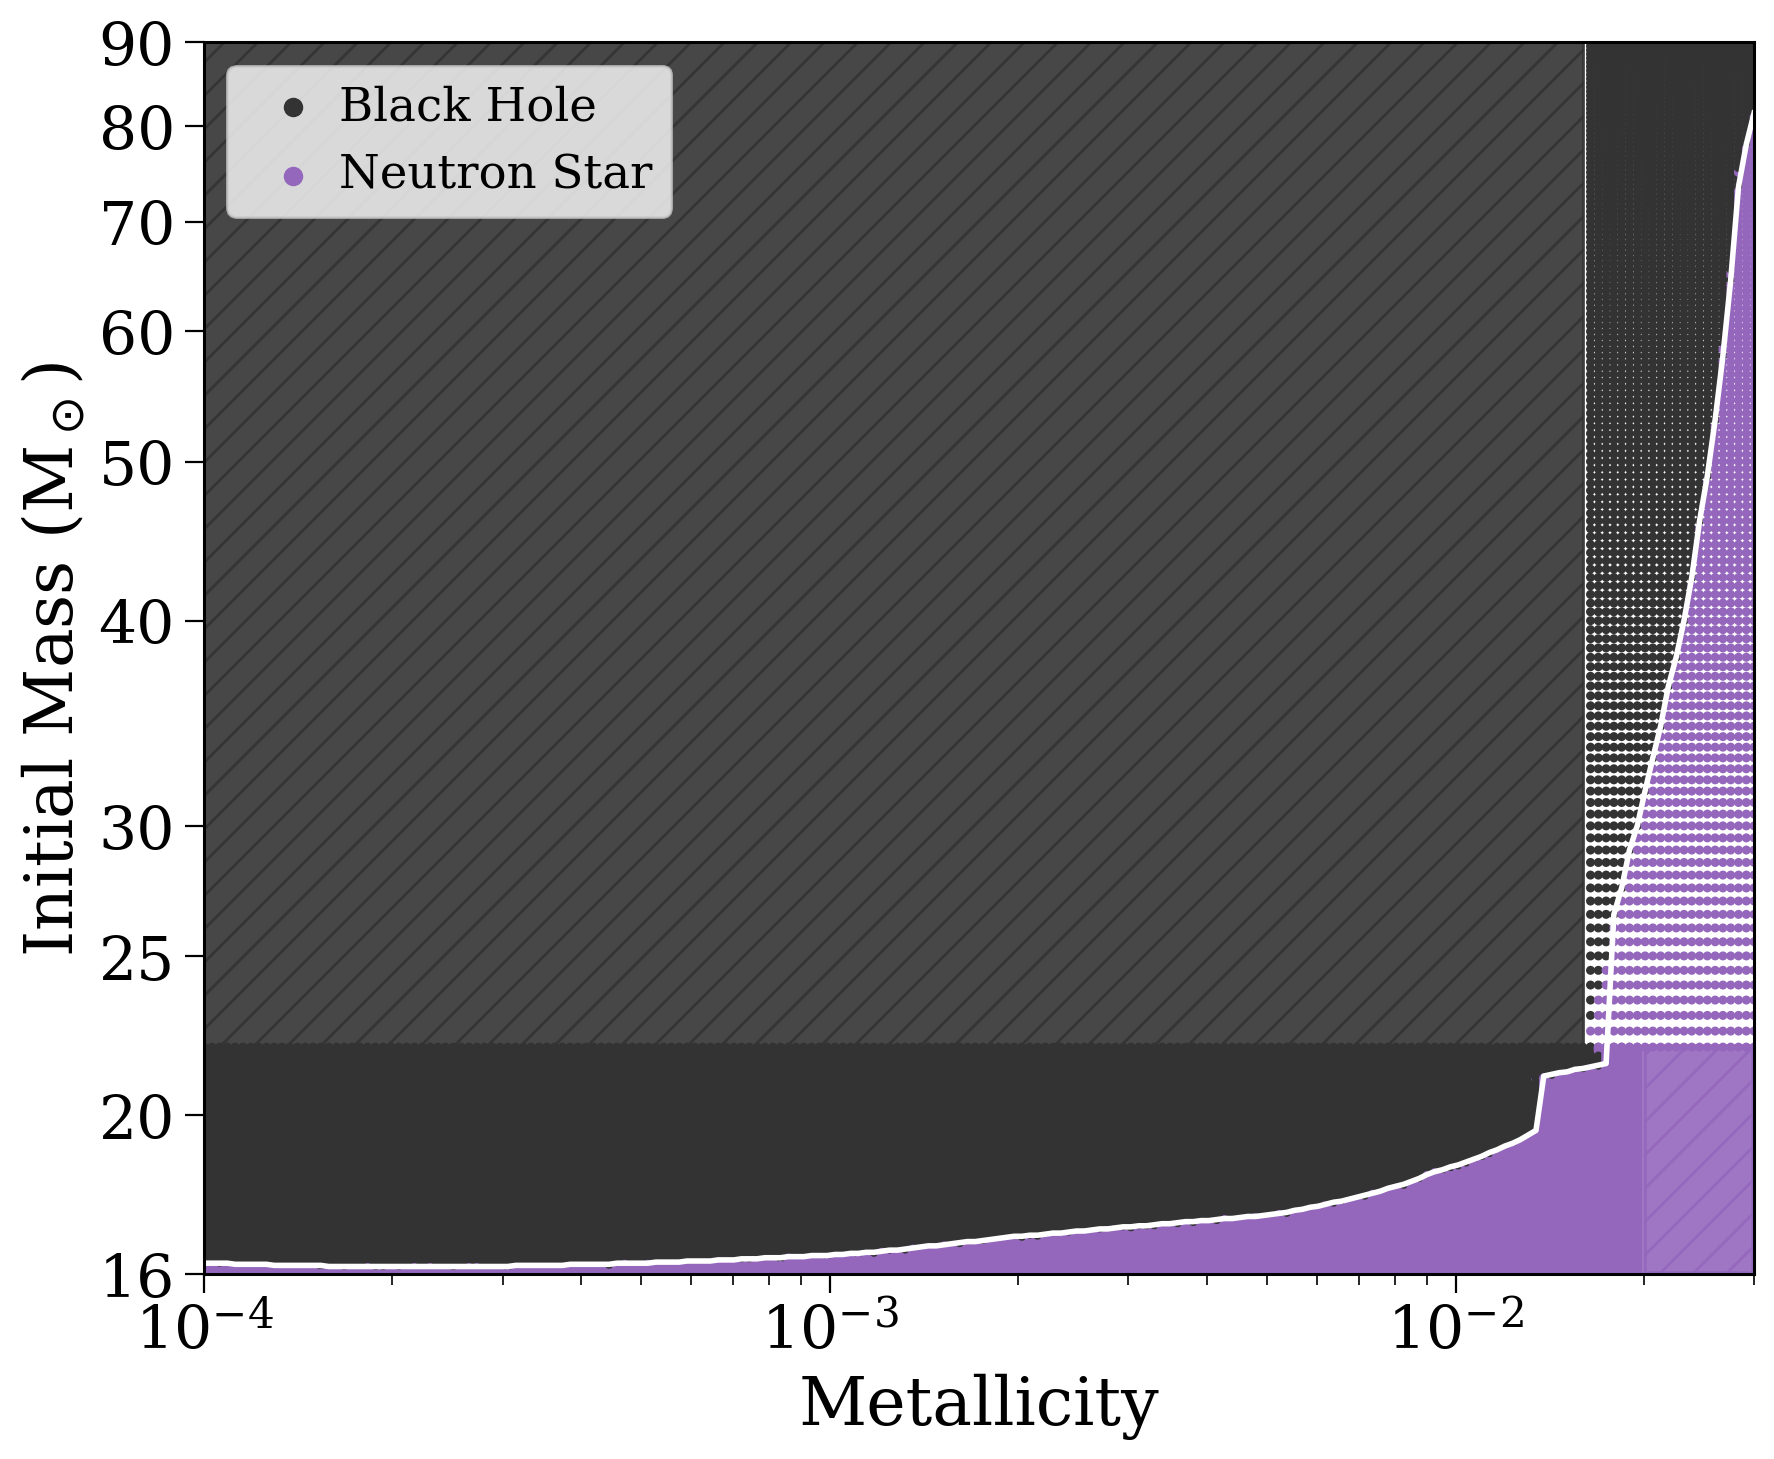

In [103]:
fig, ax = plt.subplots(figsize=(10, 8))

colours = [("#333" if k == 14 else "tab:purple") for k in final_bpp['kstar_1']]

ax.scatter(initC["metallicity"], initC["mass_1"],
           c=colours,
           s=5,
           rasterized=True)

ax.plot(min_exploding_mass["metallicity"], min_exploding_mass["mass_1"],
        color='white', lw=2)

ax.fill_between(
    [1e-4, 1.6e-2],
    [22, 22],
    [90, 90],
    color='#333',
    hatch='//',
    alpha=.9
)

ax.fill_between(
    [2e-2, 0.03],
    [16, 16],
    [22, 22],
    color='tab:purple',
    hatch='//',
    alpha=.9,
    lw=2
)

# ax.fill_between(

# ax.annotate('All form black holes', xy=(0.5, 0.5), xycoords='axes fraction',
#             fontsize=0.5*fs, color='white', ha='center', va='bottom')
# ax.annotate('All Core-Collapse', xy=(0.5, 0.99), xycoords='axes fraction',
#             fontsize=0.5*fs, color='white', ha='center', va='top')

for k in [14, 13]:
    ax.scatter(
        np.nan, np.nan,
        c="#333" if k == 14 else "tab:purple",
        label=cogsworth.utils.kstar_translator[k]["long"],
    )

ax.legend(loc='upper left', handletextpad=0.0, ncol=1)

ax.set(
    xlabel="Metallicity",
    ylabel="Initial Mass (M$_\odot$)",
    xscale="log",
    yscale="log",
    xlim=(1e-4, 0.03),
    ylim=(16, 90),
)

ax.set_yticks([16, 20, 25, 30, 40, 50, 60, 70, 80, 90])
ax.set_yticklabels([16, 20, 25, 30, 40, 50, 60, 70, 80, 90])

# plt.savefig("../plots/cosmic_bh_crit.pdf", format="pdf", bbox_inches='tight')
plt.show()

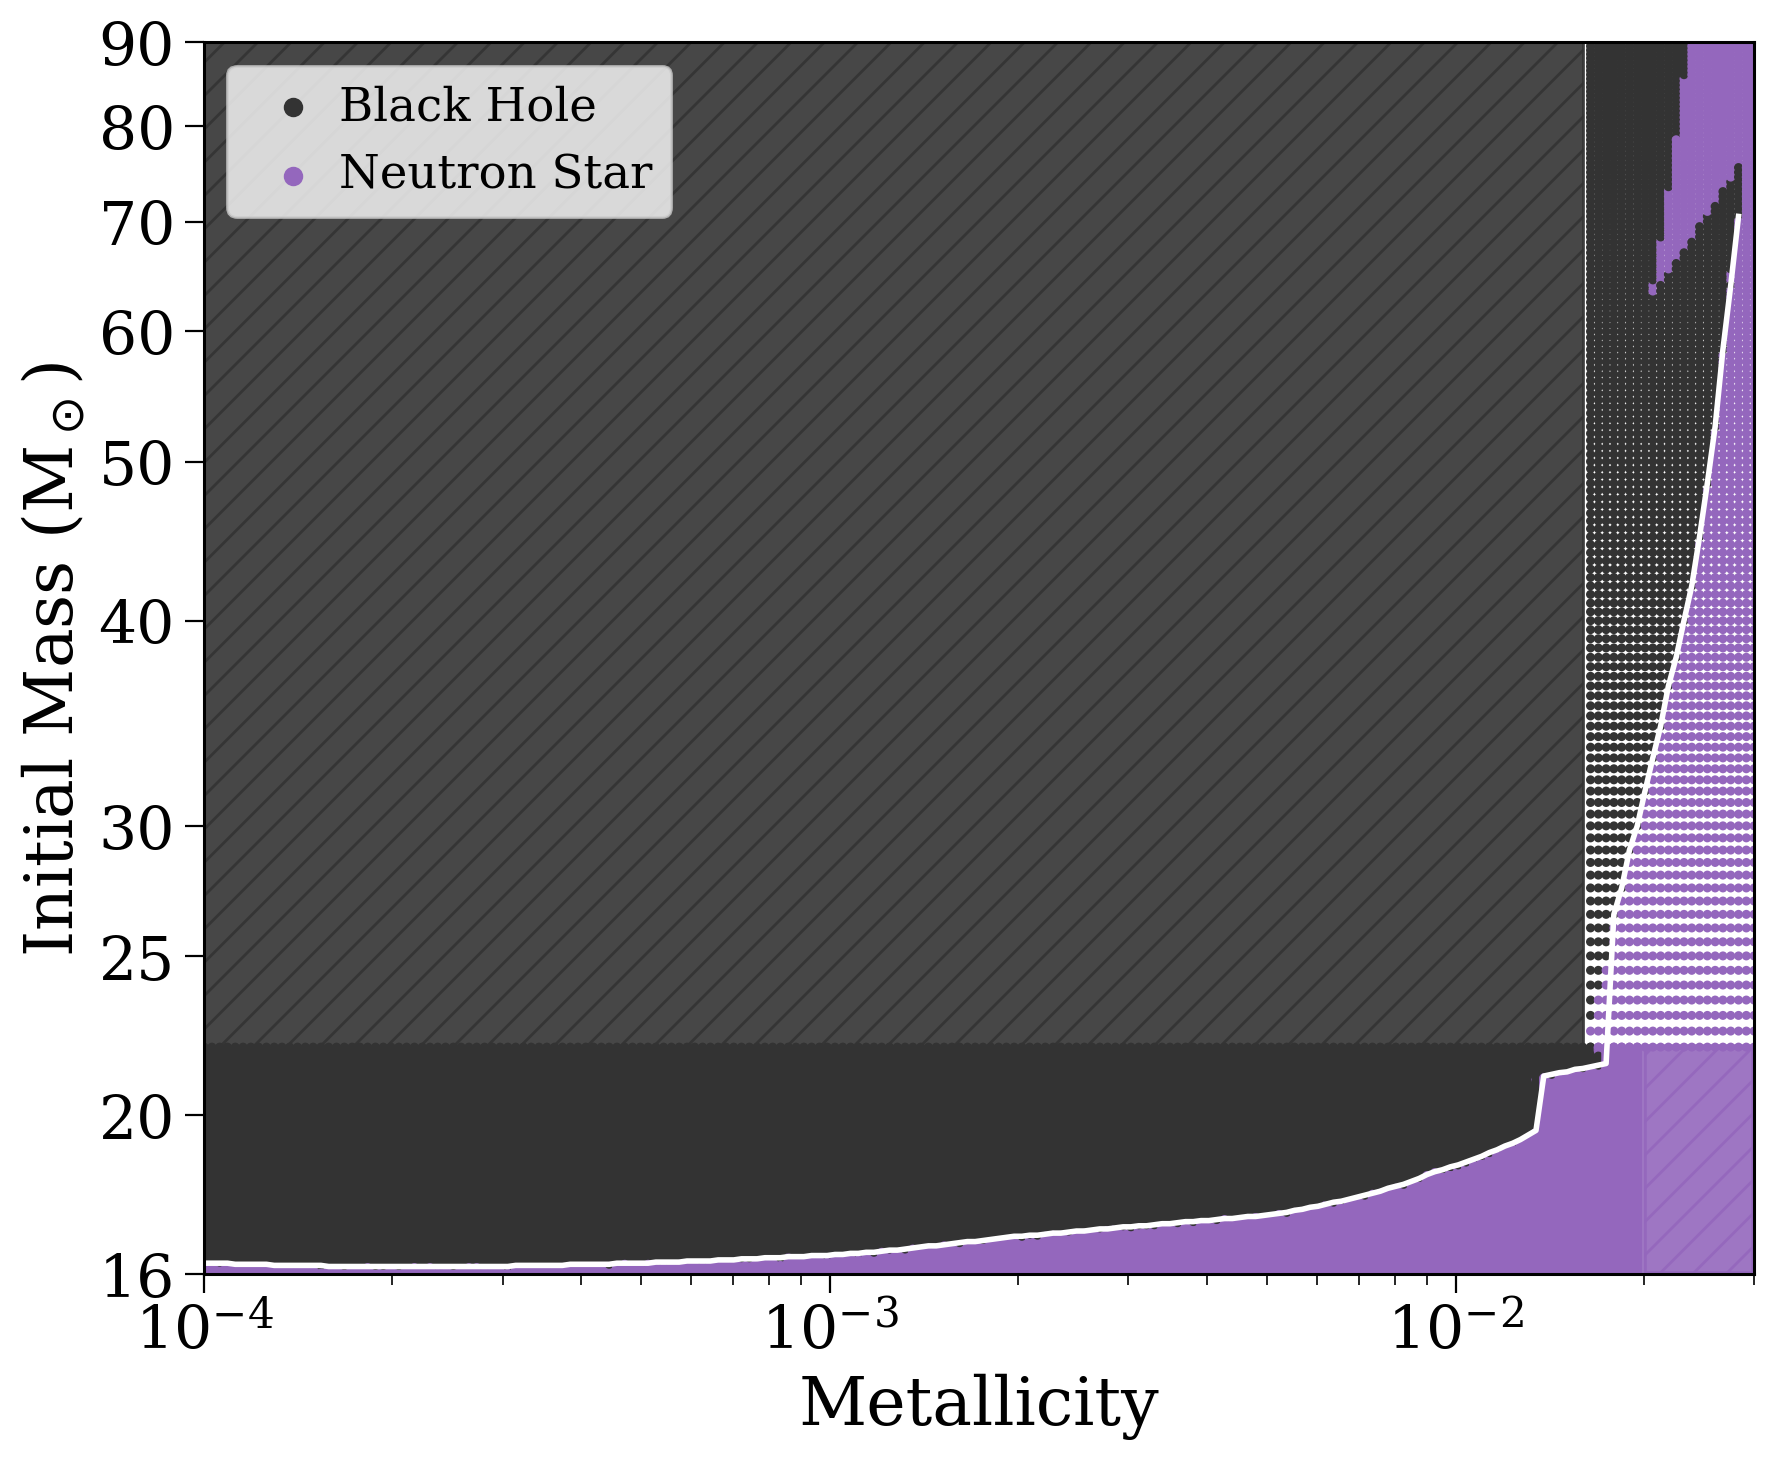

In [39]:
fig, ax = plt.subplots(figsize=(10, 8))

colours = [("#333" if k == 14 else "tab:purple") for k in final_bpp['kstar_1']]

ax.scatter(initC["metallicity"], initC["mass_1"],
           c=colours,
           s=5,
           rasterized=True)

ax.plot(min_exploding_mass["metallicity"], min_exploding_mass["mass_1"],
        color='white', lw=2)

ax.fill_between(
    [1e-4, 1.6e-2],
    [22, 22],
    [90, 90],
    color='#333',
    hatch='//',
    alpha=.9
)

ax.fill_between(
    [2e-2, 0.03],
    [16, 16],
    [22, 22],
    color='tab:purple',
    hatch='//',
    alpha=.9,
    lw=2
)

# ax.fill_between(

# ax.annotate('All form black holes', xy=(0.5, 0.5), xycoords='axes fraction',
#             fontsize=0.5*fs, color='white', ha='center', va='bottom')
# ax.annotate('All Core-Collapse', xy=(0.5, 0.99), xycoords='axes fraction',
#             fontsize=0.5*fs, color='white', ha='center', va='top')

for k in [14, 13]:
    ax.scatter(
        np.nan, np.nan,
        c="#333" if k == 14 else "tab:purple",
        label=cogsworth.utils.kstar_translator[k]["long"],
    )

ax.legend(loc='upper left', handletextpad=0.0, ncol=1)

ax.set(
    xlabel="Metallicity",
    ylabel="Initial Mass (M$_\odot$)",
    xscale="log",
    yscale="log",
    xlim=(1e-4, 0.03),
    ylim=(16, 90),
)

ax.set_yticks([16, 20, 25, 30, 40, 50, 60, 70, 80, 90])
ax.set_yticklabels([16, 20, 25, 30, 40, 50, 60, 70, 80, 90])

# plt.savefig("../plots/cosmic_bh_crit.pdf", format="pdf", bbox_inches='tight')
plt.show()

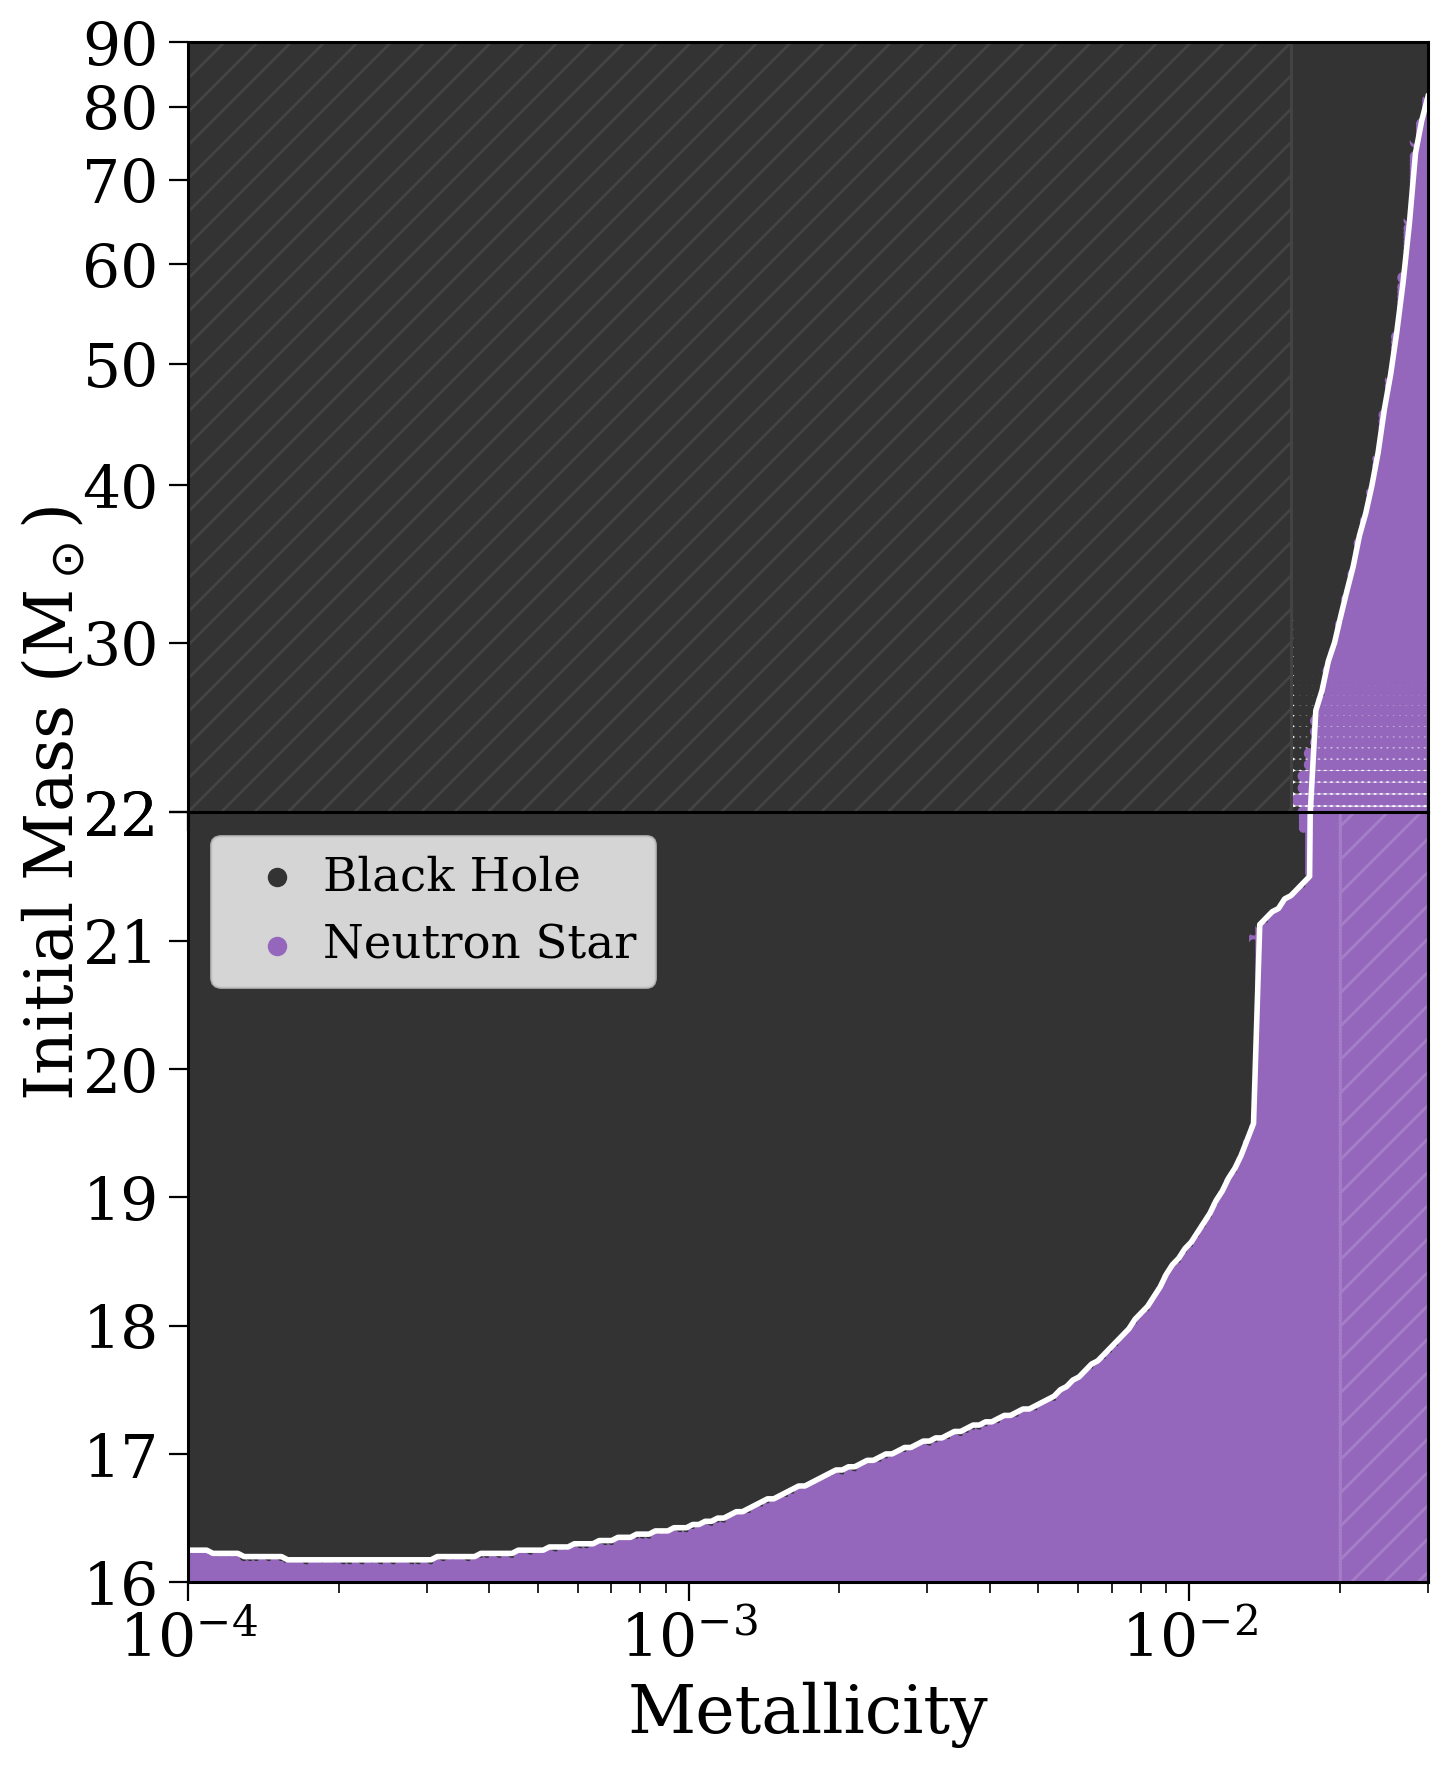

In [134]:
fig, axes = plt.subplots(2, 1, figsize=(8, 10), sharex=True)
colours = [("#333" if k == 14 else "tab:purple") for k in final_bpp['kstar_1']]

fig.subplots_adjust(hspace=0.0)

for ax, m_lims, scale, s in zip(axes, [(22, 90), (16, 22)], ['log', 'linear'], [10, 5]):
    ax.scatter(initC["metallicity"], initC["mass_1"],
            c=colours,
            s=s,
            rasterized=True)

    ax.plot(min_exploding_mass["metallicity"], min_exploding_mass["mass_1"],
            color='white', lw=2)

    ax.fill_between(
        [1e-4, 1.6e-2],
        [22, 22],
        [90, 90],
        color='#333',
    )
    ax.fill_between(
        [1e-4, 1.6e-2],
        [22, 22],
        [90, 90],
        facecolor='none',
        edgecolor='#444',
        hatch='//',
    )

    ax.fill_between(
        [2e-2, 0.03],
        [16, 16],
        [22, 22],
        color='tab:purple',
    )
    ax.fill_between(
        [2e-2, 0.03],
        [16, 16],
        [22, 22],
        facecolor='none',
        edgecolor='#a47ec7',
        hatch='//',
    )

    for k in [14, 13]:
        ax.scatter(
            np.nan, np.nan,
            c="#333" if k == 14 else "tab:purple",
            label=cogsworth.utils.kstar_translator[k]["long"],
        )

    ax.set(
        xlabel="Metallicity" if ax == axes[-1] else "",
        # ylabel="Initial Mass (M$_\odot$)",
        xscale="log",
        yscale=scale,
        xlim=(1e-4, 0.03),
        ylim=m_lims,
    )

axes[0].set_yticks([22, 30, 40, 50, 60, 70, 80, 90])
axes[0].set_yticklabels([22, 30, 40, 50, 60, 70, 80, 90])
axes[1].legend(loc='upper left', handletextpad=0.0, ncol=1)

fig.supylabel("Initial Mass (M$_\odot$)", fontsize=fs)

plt.savefig("../plots/cosmic_bh_crit.pdf", format="pdf", bbox_inches='tight')
plt.show()

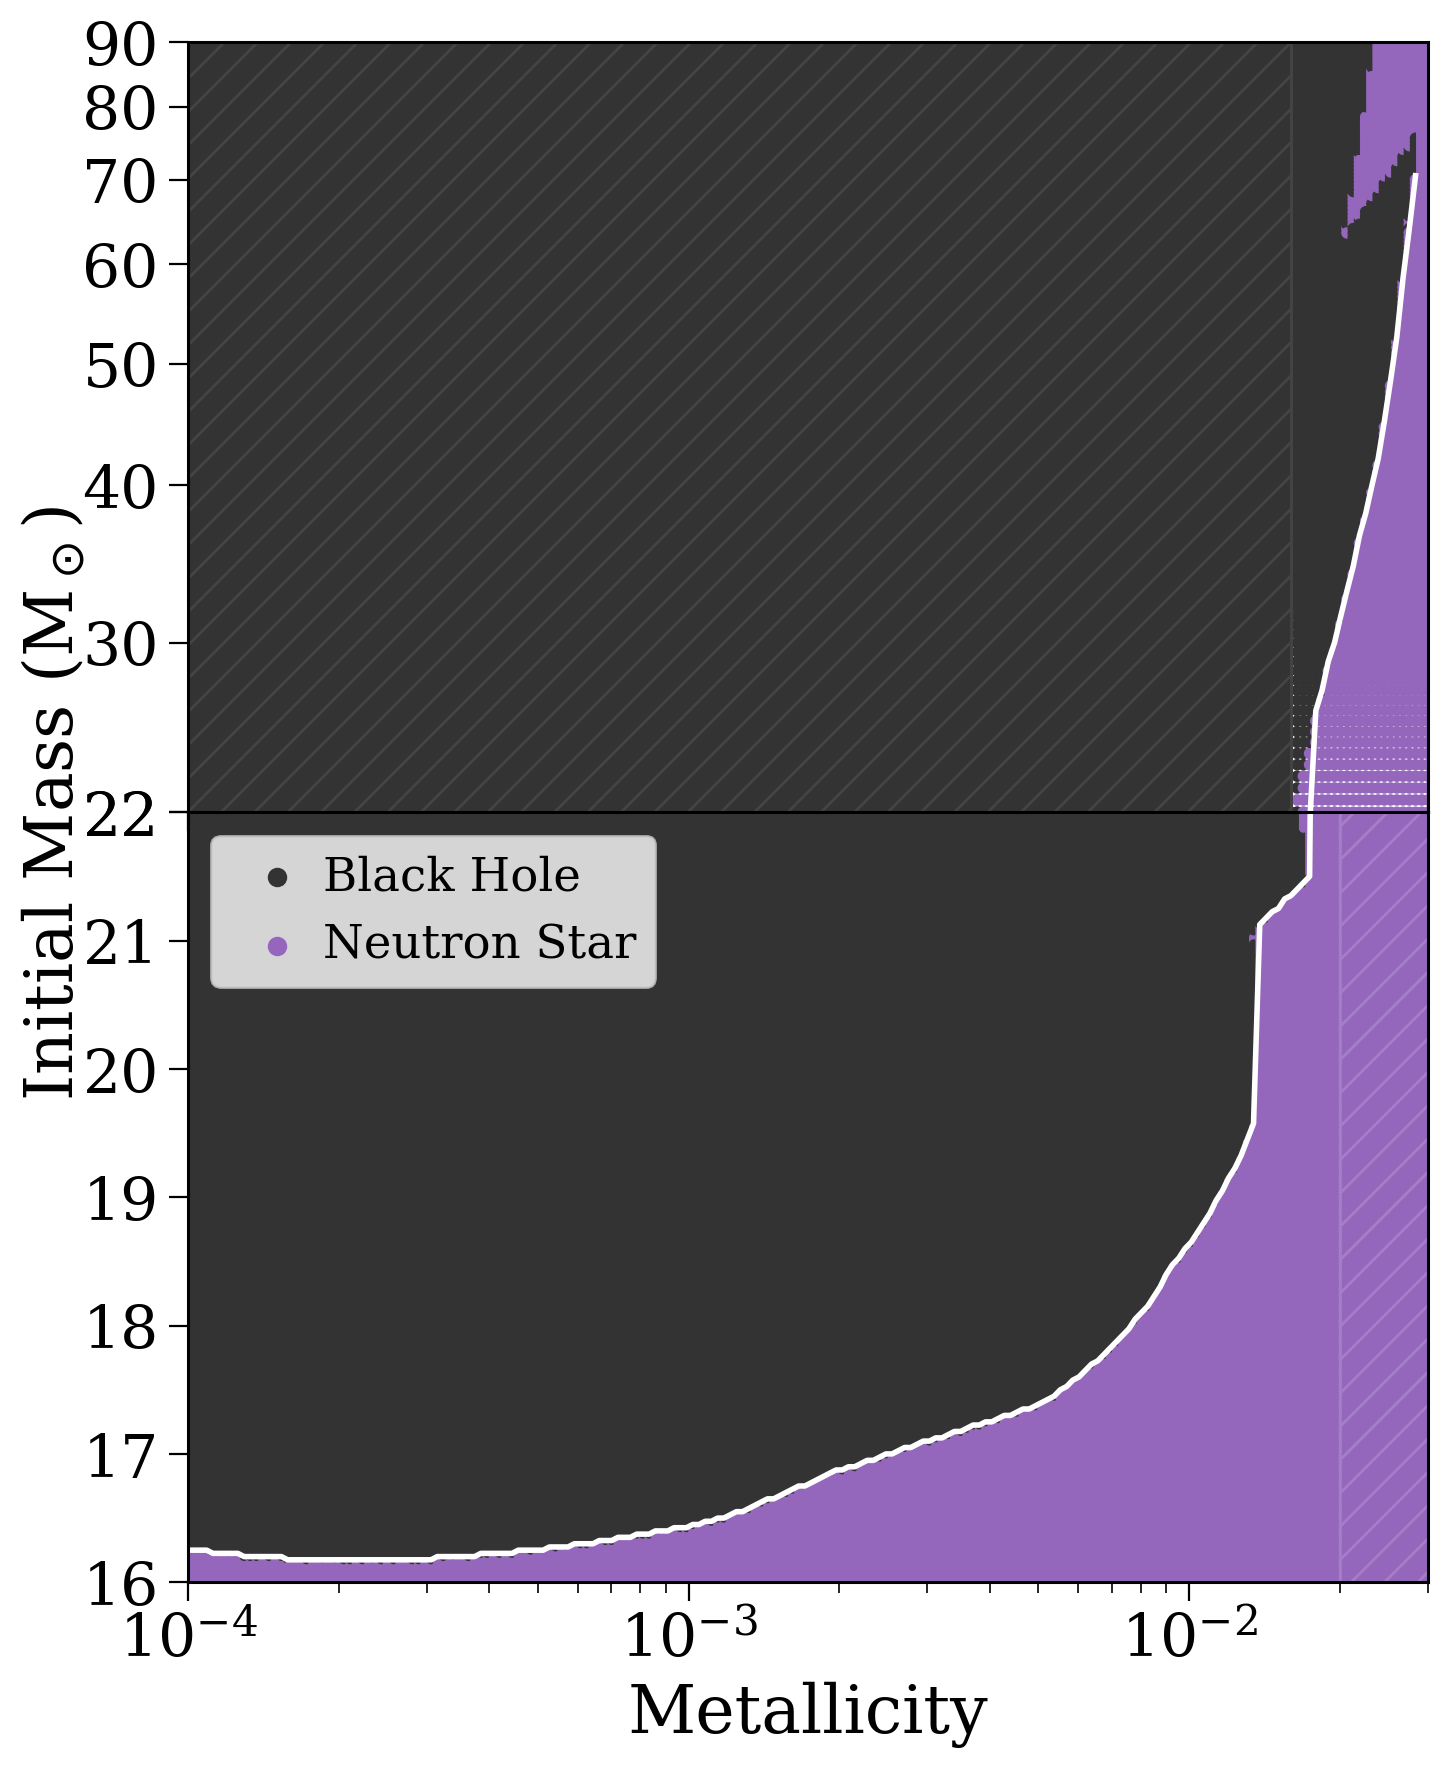

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(8, 10), sharex=True)
colours = [("#333" if k == 14 else "tab:purple") for k in final_bpp['kstar_1']]

fig.subplots_adjust(hspace=0.0)

for ax, m_lims, scale, s in zip(axes, [(22, 90), (16, 22)], ['log', 'linear'], [10, 5]):
    ax.scatter(initC["metallicity"], initC["mass_1"],
            c=colours,
            s=s,
            rasterized=True)

    ax.plot(min_exploding_mass["metallicity"], min_exploding_mass["mass_1"],
            color='white', lw=2)

    ax.fill_between(
        [1e-4, 1.6e-2],
        [22, 22],
        [90, 90],
        color='#333',
    )
    ax.fill_between(
        [1e-4, 1.6e-2],
        [22, 22],
        [90, 90],
        facecolor='none',
        edgecolor='#444',
        hatch='//',
    )

    ax.fill_between(
        [2e-2, 0.03],
        [16, 16],
        [22, 22],
        color='tab:purple',
    )
    ax.fill_between(
        [2e-2, 0.03],
        [16, 16],
        [22, 22],
        facecolor='none',
        edgecolor='#a47ec7',
        hatch='//',
    )

    for k in [14, 13]:
        ax.scatter(
            np.nan, np.nan,
            c="#333" if k == 14 else "tab:purple",
            label=cogsworth.utils.kstar_translator[k]["long"],
        )

    ax.set(
        xlabel="Metallicity" if ax == axes[-1] else "",
        # ylabel="Initial Mass (M$_\odot$)",
        xscale="log",
        yscale=scale,
        xlim=(1e-4, 0.03),
        ylim=m_lims,
    )

axes[0].set_yticks([22, 30, 40, 50, 60, 70, 80, 90])
axes[0].set_yticklabels([22, 30, 40, 50, 60, 70, 80, 90])
axes[1].legend(loc='upper left', handletextpad=0.0, ncol=1)

fig.supylabel("Initial Mass (M$_\odot$)", fontsize=fs)

# plt.savefig("../plots/cosmic_bh_crit.pdf", format="pdf", bbox_inches='tight')
plt.show()